# 🧬 Bio-JEPA — Phase 3 : Visualisation & Repositionnement FDA
**Démonstration du caractère sémantique de l'espace latent + Repositionnement de médicaments**

---

## ⚙️ Avant de commencer
1. `Runtime → Change runtime type → A100 GPU`
2. Avoir les checkpoints sur Google Drive depuis la Phase 1/2
3. Exécuter les cellules dans l'ordre

---

## 📋 Plan
| Étape | Description | Durée estimée |
|---|---|---|
| 0 | GPU + Google Drive | 2 min |
| 1 | Dépendances + Clone repo | 3 min |
| 2 | Récupération checkpoints depuis Drive | 1 min |
| 3 | Visualisation UMAP espace latent | ~10 min |
| 4 | Repositionnement molécules FDA | ~30 min |
| 5 | Sauvegarde résultats sur Drive | 1 min |

---
## Étape 0 — Vérification GPU & Google Drive

In [1]:
import torch
!nvidia-smi
print(f'\n✓ PyTorch : {torch.__version__}')
print(f'✓ CUDA disponible : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'✓ GPU : {torch.cuda.get_device_name(0)}')
    print(f'✓ VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Sat Mar  7 14:10:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             43W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/Bio-JEPA-checkpoints'
RESULTS_PATH = '/content/drive/MyDrive/Bio-JEPA-results'
os.makedirs(RESULTS_PATH, exist_ok=True)

print(f'✓ Google Drive monté')
print(f'✓ Checkpoints : {DRIVE_PATH}')
print(f'✓ Résultats   : {RESULTS_PATH}')
print('\nFichiers disponibles sur Drive :')
!ls -lh {DRIVE_PATH}

Mounted at /content/drive
✓ Google Drive monté
✓ Checkpoints : /content/drive/MyDrive/Bio-JEPA-checkpoints
✓ Résultats   : /content/drive/MyDrive/Bio-JEPA-results

Fichiers disponibles sur Drive :
total 25M
-rw------- 1 root root  13M Mar  6 13:02 best_model.pt
-rw------- 1 root root  64K Mar  6 13:03 few_shot_curve.png
-rw------- 1 root root 1.3K Mar  6 13:02 few_shot_indomain.json
-rw------- 1 root root 1.3K Mar  6 13:02 few_shot_transfer.json
-rw------- 1 root root  13M Mar  6 11:18 zinc_pretrained.pt


---
## Étape 1 — Dépendances & Clone du repo

In [3]:
!pip install torch_geometric rdkit pandas numpy scikit-learn tqdm requests pyyaml chembl-webresource-client umap-learn -q
print('✓ Toutes les dépendances installées')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 9.7 MB/s eta 0:00:00
✓ Toutes les dépendances installées


In [4]:
!git clone https://github.com/7Nayy/Bio-JEPA.git /content/Bio-JEPA
os.chdir('/content/Bio-JEPA')
print(f'✓ Repo cloné — dossier courant : {os.getcwd()}')
!ls -la

Cloning into '/content/Bio-JEPA'...
remote: Enumerating objects: 92, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 92 (delta 5), reused 26 (delta 3), pack-reused 54 (from 2)
Receiving objects: 100% (92/92), 48.10 MiB | 25.88 MiB/s, done.
Resolving deltas: 100% (8/8), done.
✓ Repo cloné — dossier courant : /content/Bio-JEPA
total 800
drwxr-xr-x 10 root root   4096 Mar  6 13:47 .
drwxr-xr-x  1 root root   4096 Mar  6 13:47 ..
-rw-r--r--  1 root root  22223 Mar  6 13:47 baseline.py
drwxr-xr-x  2 root root   4096 Mar  6 13:47 checkpoints
-rw-r--r--  1 root root   4230 Mar  6 13:47 CLAUDE.md
drwxr-xr-x  2 root root   4096 Mar  6 13:47 configs
drwxr-xr-x  4 root root   4096 Mar  6 13:47 data
drwxr-xr-x  3 root root   4096 Mar  6 13:47 evaluation
-rw-r--r--  1 root root  33999 Mar  6 13:47 few_shot_eval.py
drwxr-xr-x  8 root root   4096 Mar  6 13:47 .git
drwxr-xr-x  3 root root   4096 Mar  6 13:47 models
-rw-r--r--  1 root r

---
## Étape 2 — Récupération des checkpoints depuis Google Drive
> Les checkpoints ont été sauvegardés lors de la Phase 1/2

In [5]:
import shutil

os.makedirs('checkpoints', exist_ok=True)
os.makedirs('results', exist_ok=True)

checkpoints = {
    f'{DRIVE_PATH}/zinc_pretrained.pt' : 'checkpoints/zinc_pretrained.pt',
    f'{DRIVE_PATH}/best_model.pt'      : 'checkpoints/best_model.pt',
}

for src, dst in checkpoints.items():
    if os.path.exists(src):
        shutil.copy(src, dst)
        size_mb = os.path.getsize(dst) / 1e6
        print(f'✓ {dst} ({size_mb:.1f} MB)')
    else:
        print(f'❌ Introuvable : {src}')
        print('   Relancer la Phase 1/2 pour générer les checkpoints')

✓ checkpoints/zinc_pretrained.pt (13.0 MB)
✓ checkpoints/best_model.pt (13.0 MB)


---
## Étape 3 — Visualisation UMAP de l'espace latent

> **Objectif** : Démontrer que l'espace latent Bio-JEPA est **sémantique**  
> Les molécules de haute affinité doivent se regrouper dans l'espace latent  
> **Durée estimée** : ~10 min sur A100

In [6]:
!python umap_viz.py --checkpoint checkpoints/zinc_pretrained.pt --target CHEMBL251

2026-03-06 13:48:01.204055: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-06 13:48:01.222556: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772804881.244907    1138 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772804881.252224    1138 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772804881.271378    1138 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

--- umap_affinity.png ---


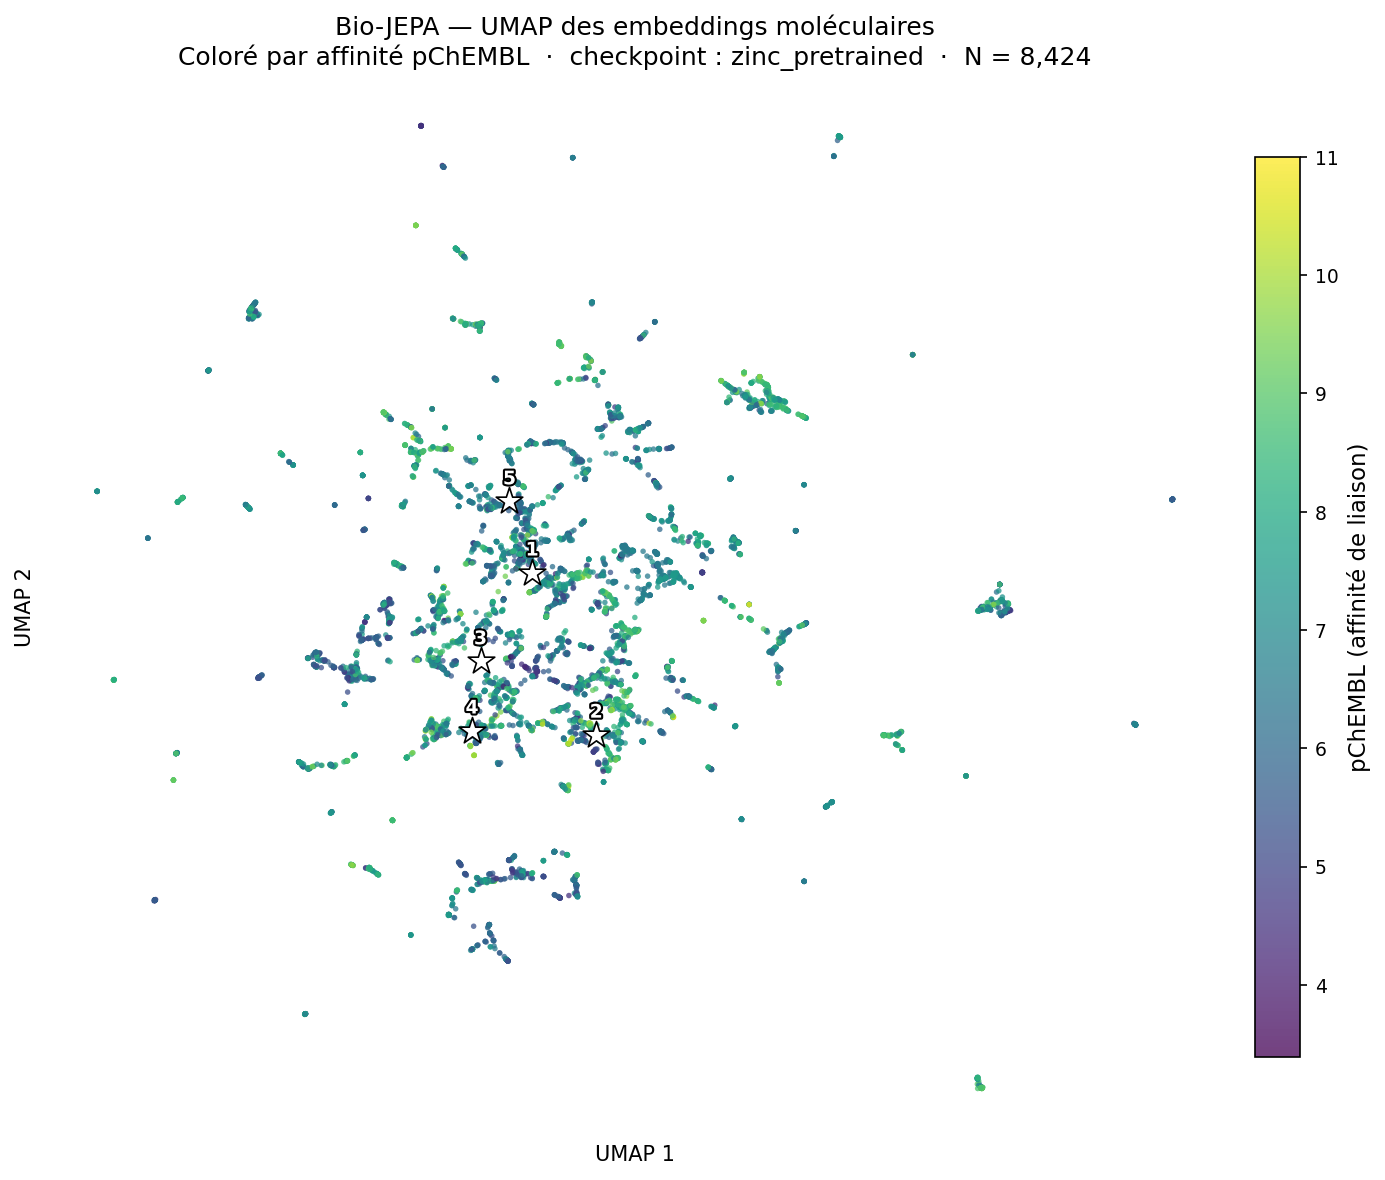

--- umap_scaffold.png ---


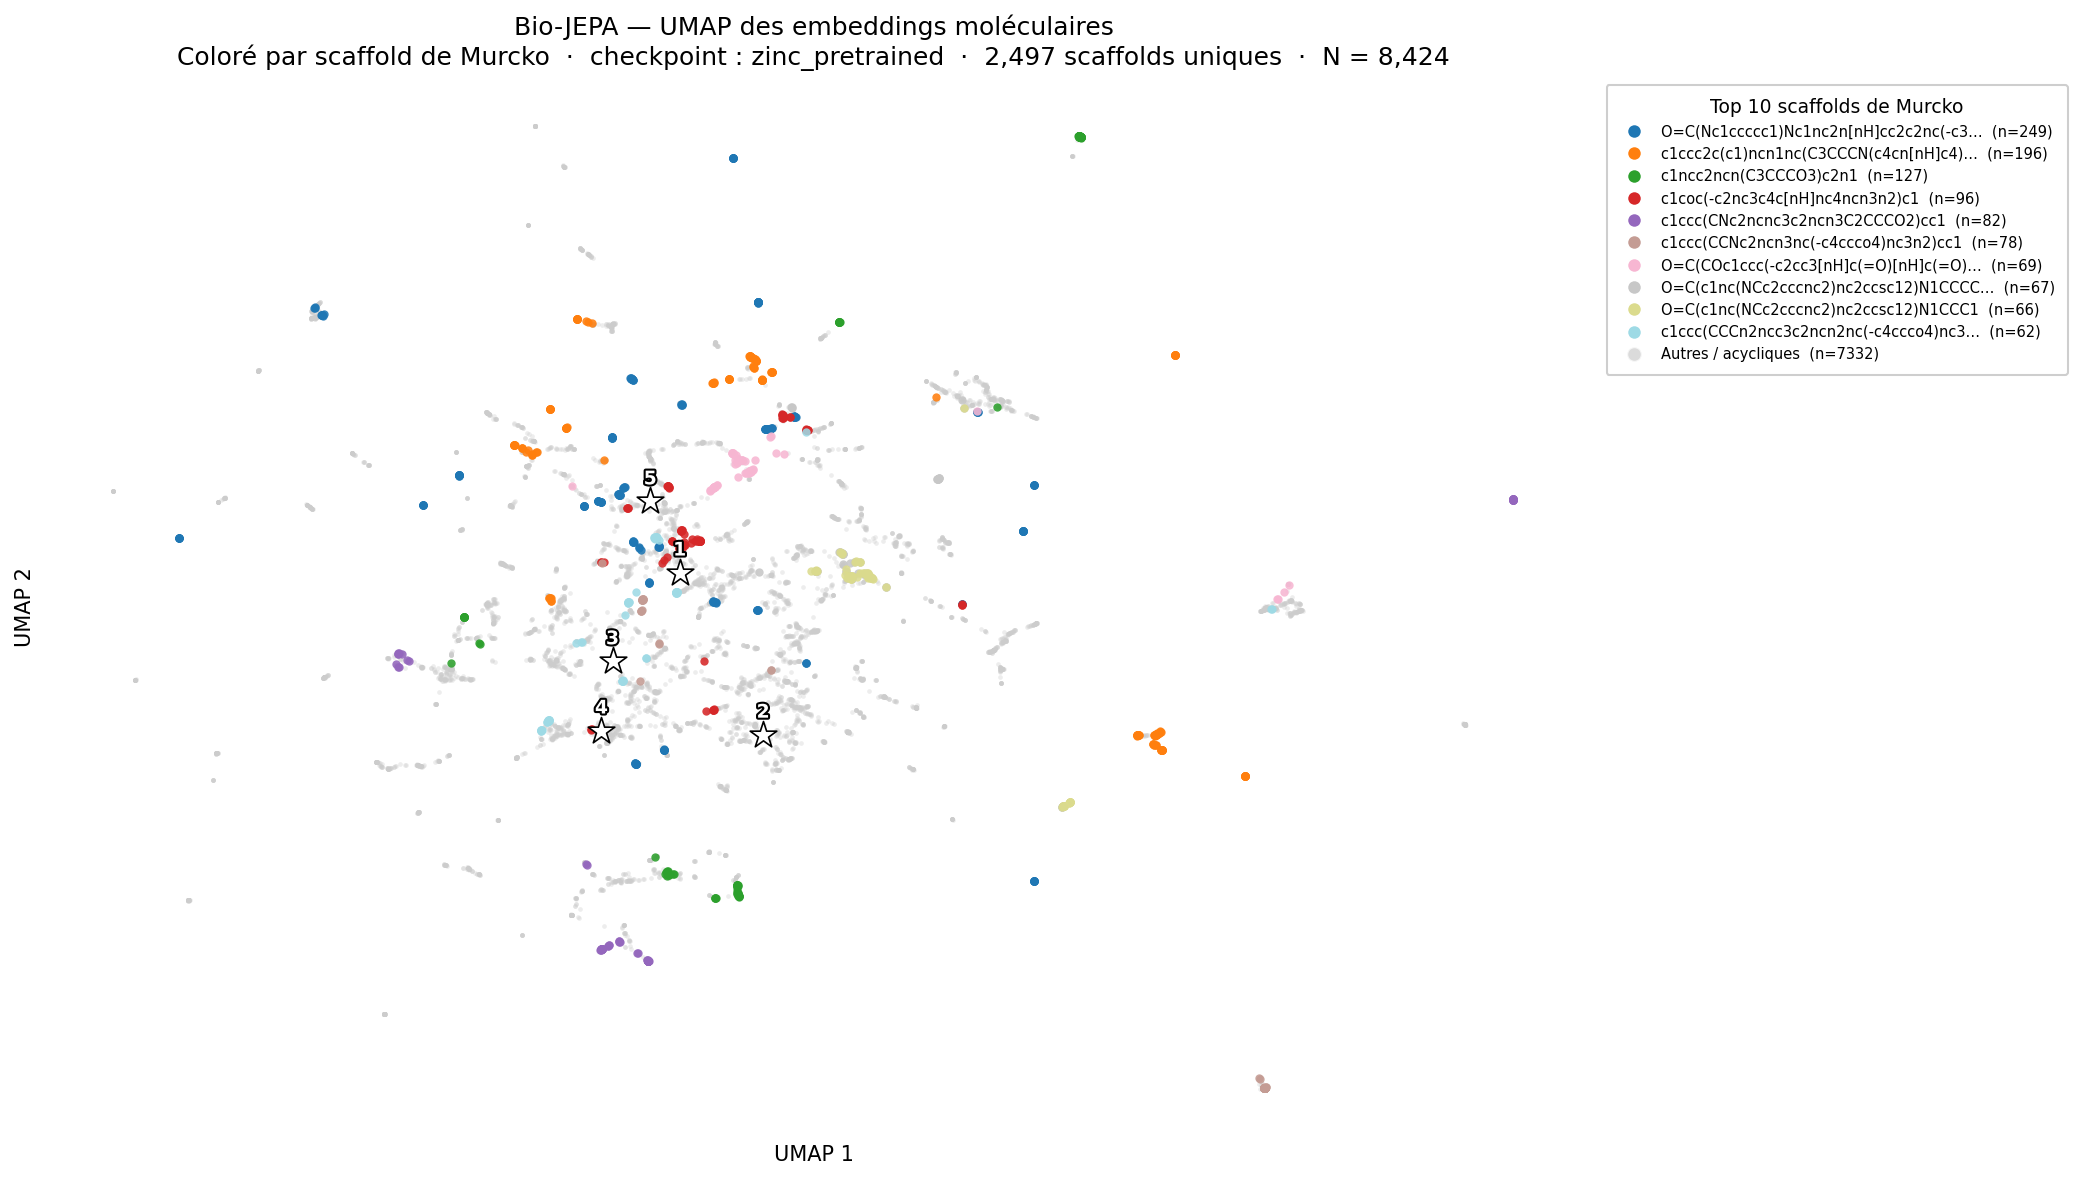

In [7]:
# Affichage des figures UMAP dans le notebook
from IPython.display import Image, display
import os

for fig_name in ['umap_affinity.png', 'umap_scaffold.png']:
    fig_path = f'results/{fig_name}'
    if os.path.exists(fig_path):
        print(f'--- {fig_name} ---')
        display(Image(fig_path))
    else:
        print(f'❌ {fig_path} introuvable')

---
## Étape 4 — Repositionnement de médicaments FDA

> **Objectif** : Identifier parmi les médicaments FDA approuvés ceux qui pourraient
> être repositionnés sur le récepteur A2A (CHEMBL251)  
> C'est le **cœur du titre** de ton papier  
> **Durée estimée** : ~30 min sur A100

In [10]:
!python repositioning.py \
    --checkpoint checkpoints/zinc_pretrained.pt \
    --target CHEMBL251 \
    --retrain-probe \
    --top-k 20 \
    --out-dir results/

[Dispositif] cuda

[Encodeur] checkpoints/zinc_pretrained.pt
  Target Encoder : 407,044 params

[Sonde MLP] Cible : CHEMBL251
  Entraînement de la sonde (forcé)...
  Extraction des embeddings ChEMBL251...
  8424 molécules  |  embedding_dim=256
    Epoch  50/200  loss=3.8946
    Epoch 100/200  loss=0.4259
    Epoch 150/200  loss=0.3093
    Epoch 200/200  loss=0.2974
  Meilleure loss : 0.2974
  Sonde sauvegardée → checkpoints/probe_chembl251.pt
[Médicaments FDA]
  GitHub inaccessible (404 Client Error: Not Found for url: https://raw.githubusercontent.com/chembl/chembl_webresource_client/master/chembl_webresource_client/test_data/approved_drugs.csv)
  API ChEMBL (max_phase=4)...
  3229 médicaments valides récupérés
  → 3229 médicaments retenus

[Encodage] 3229 médicaments → Target Encoder...
[13:58:27] WARNING: not removing hydrogen atom without neighbors
[13:58:27] WARNING: not removing hydrogen atom without neighbors
[13:58:27] WARNING: not removing hydrogen atom without neighbors
[13:5

In [13]:
import json
import pandas as pd

with open('results/repositioning_results.json') as f:
    results = json.load(f)

meta = results['metadata']
print('=== METADATA ===')
print(f'Molécules FDA screenées : {meta["n_fda_drugs_screened"]}')
print(f'Score min : {meta["score_stats"]["min"]:.2f}')
print(f'Score max : {meta["score_stats"]["max"]:.2f}')
print(f'Score moyen : {meta["score_stats"]["mean"]:.2f}')

print('\n=== TOP-20 CANDIDATS AU REPOSITIONNEMENT ===')
print(f'Cible : {meta["chembl_target"]} (Récepteur A2A)\n')

df = pd.DataFrame(results['top20'])
pd.set_option('display.max_colwidth', 40)
print(df.to_string(index=False))

=== METADATA ===
Molécules FDA screenées : 3229
Score min : 3.10
Score max : 8.61
Score moyen : 5.50

=== TOP-20 CANDIDATS AU REPOSITIONNEMENT ===
Cible : CHEMBL251 (Récepteur A2A)

                               name     chembl_id                                                                             smiles  predicted_pchembl                           indication  rank
                        RALTEGRAVIR  CHEMBL254316                        Cc1nnc(C(=O)NC(C)(C)c2nc(C(=O)NCc3ccc(F)cc3)c(O)c(=O)n2C)o1             8.6097          Anti-infectieux systémiques     1
                  ENALAPRIL MALEATE CHEMBL1200659        CCOC(=O)[C@H](CCc1ccccc1)N[C@@H](C)C(=O)N1CCC[C@H]1C(=O)O.O=C(O)/C=C\C(=O)O             8.5589                        Non spécifiée     2
              RALTEGRAVIR POTASSIUM  CHEMBL518520                Cc1nnc(C(=O)NC(C)(C)c2nc(C(=O)NCc3ccc(F)cc3)c([O-])c(=O)n2C)o1.[K+]             8.5299                        Non spécifiée     3
                           ATALUREN  C

---
## Étape 5 — Sauvegarde finale sur Google Drive

In [15]:
import shutil, os

fichiers = {
    'results/umap_affinity.png'          : 'umap_affinity.png',
    'results/umap_scaffold.png'          : 'umap_scaffold.png',
    'results/repositioning_results.json' : 'repositioning_results.json',
}

for src, dst in fichiers.items():
    if os.path.exists(src):
        shutil.copy(src, f'{RESULTS_PATH}/{dst}')
        size_mb = os.path.getsize(f'{RESULTS_PATH}/{dst}') / 1e6
        print(f'✓ {dst} ({size_mb:.1f} MB)')
    else:
        print(f'⚠️  {src} introuvable')

print('\n✅ PHASE 3 TERMINÉE')
print(f'📁 Résultats disponibles dans : {RESULTS_PATH}')

✓ umap_affinity.png (0.2 MB)
✓ umap_scaffold.png (0.2 MB)
✓ repositioning_results.json (0.0 MB)

✅ PHASE 3 TERMINÉE
📁 Résultats disponibles dans : /content/drive/MyDrive/Bio-JEPA-results
